<a href="https://colab.research.google.com/github/LokeshDerangula00/Hlo-NEC/blob/master/google.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("sales_dataset_task2_task3.csv")

In [ ]:
df.head()

,Order_ID,Date,Product,Category,Region,Sales,Quantity,Profit
0,1001,2026-01-05,Laptop,Technology,Hyderabad,65000,2,8000
1,1002,2026-01-08,Mobile,Technology,Bengaluru,30000,3,4500
2,1003,2026-01-12,Chair,Furniture,Chennai,12000,5,2500
3,1004,2026-01-18,Table,Furniture,Hyderabad,18000,2,3500
4,1005,2026-01-23,Headphones,Technology,Mumbai,5000,10,1200


In [ ]:
df.shape

(20, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  20 non-null     int64 
 1   Date      20 non-null     object
 2   Product   20 non-null     object
 3   Category  20 non-null     object
 4   Region    20 non-null     object
 5   Sales     20 non-null     int64 
 6   Quantity  20 non-null     int64 
 7   Profit    20 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 1.4+ KB


In [ ]:
df.describe()

,Order_ID,Sales,Quantity,Profit
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,21800.000000,4.550000,3470.000000
std,5.91608,18059.404898,2.981963,2145.276329
min,1001.00000,4000.000000,2.000000,900.000000
25%,1005.75000,11750.000000,2.000000,2325.000000
50%,1010.50000,17000.000000,3.500000,3050.000000
75%,1015.25000,27250.000000,5.250000,4050.000000
max,1020.00000,72000.000000,12.000000,9500.000000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product,0
Category,0
Region,0
Sales,0
Quantity,0
Profit,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Furniture,118500
Technology,317500


In [ ]:
df.groupby("Region")["Sales"].sum()

,Sales
Region,
Bengaluru,63500
Chennai,66000
Delhi,112500
Hyderabad,154000
Mumbai,40000


In [ ]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

,Sales
Product,
Laptop,137000
Monitor,58000
Mobile,57000
Printer,46000
Table,38000
Desk,31000
Chair,26000
Bookshelf,23500
Headphones,11000


In [ ]:
df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

,Profit
Product,
Laptop,17500
Monitor,9000
Mobile,8500
Table,7400
Printer,6500
Desk,5900
Chair,5500
Bookshelf,4500
Headphones,2700


In [ ]:
df[["Sales", "Quantity", "Profit"]].corr()

,Sales,Quantity,Profit
Sales,1.000000,-0.587179,0.986923
Quantity,-0.587179,1.000000,-0.630792
Profit,0.986923,-0.630792,1.000000


Conclusion: The dataset was analyzed using Exploratory Data Analysis. The data was checked for missing values and duplicate records. Descriptive statistics and group-wise analysis were performed to understand sales, quantity, profit, product, category, and regional patterns.

In [ ]:
#task 3 - DATA VISUALIZATION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_dataset_task2_task3.csv")

In [ ]:
df.head()

,Order_ID,Date,Product,Category,Region,Sales,Quantity,Profit
0,1001,2026-01-05,Laptop,Technology,Hyderabad,65000,2,8000
1,1002,2026-01-08,Mobile,Technology,Bengaluru,30000,3,4500
2,1003,2026-01-12,Chair,Furniture,Chennai,12000,5,2500
3,1004,2026-01-18,Table,Furniture,Hyderabad,18000,2,3500
4,1005,2026-01-23,Headphones,Technology,Mumbai,5000,10,1200


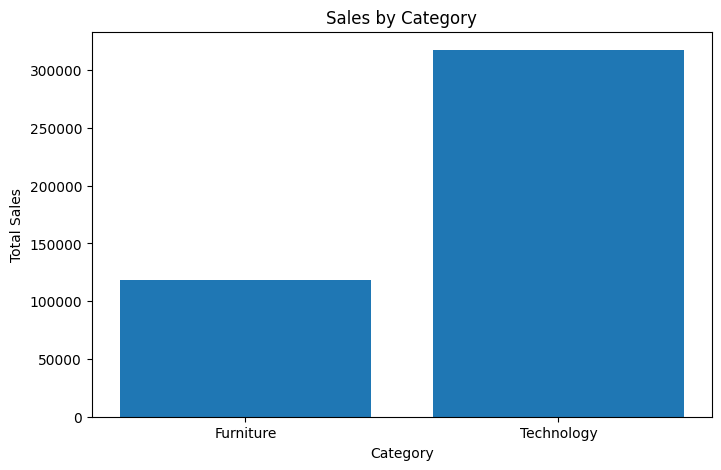

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
TASK 4 -SENTIMENT ANALYSIS

In [ ]:
import pandas as pd

reviews = {
    "Review": [
        "This product is excellent and very useful",
        "I really loved this product",
        "Amazing quality and fast delivery",
        "The product is very good",
        "I am happy with my purchase",
        "Excellent experience, highly recommended",
        "The quality is okay",
        "The product is average",
        "Delivery was on time",
        "It is an ordinary product",
        "I am not satisfied with this product",
        "Very poor quality",
        "I hate this product",
        "The product is terrible",
        "Very bad experience",
        "The product stopped working quickly",
        "Worst purchase I have ever made",
        "The quality is disappointing",
        "I would not recommend this product",
        "Completely unhappy with the purchase"
    ]
}

reviews_df = pd.DataFrame(reviews)

reviews_df.head()

,Review
0,This product is excellent and very useful
1,I really loved this product
2,Amazing quality and fast delivery
3,The product is very good
4,I am happy with my purchase


In [ ]:
from textblob import TextBlob

reviews_df["Sentiment"] = reviews_df["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews_df.head()

,Review,Sentiment
0,This product is excellent and very useful,0.695
1,I really loved this product,0.700
2,Amazing quality and fast delivery,0.400
3,The product is very good,0.910
4,I am happy with my purchase,0.800


In [ ]:
!pip install textblob

In [ ]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_df["Sentiment_Label"] = reviews_df["Sentiment"].apply(get_sentiment)

reviews_df.head()

,Review,Sentiment,Sentiment_Label
0,This product is excellent and very useful,0.695,Positive
1,I really loved this product,0.700,Positive
2,Amazing quality and fast delivery,0.400,Positive
3,The product is very good,0.910,Positive
4,I am happy with my purchase,0.800,Positive


In [ ]:
reviews_df["Sentiment_Label"].value_counts()

,count
Sentiment_Label,
Negative,10
Positive,8
Neutral,2


In [ ]:
sentiment_percentage = (
    reviews_df["Sentiment_Label"]
    .value_counts(normalize=True) * 100
)

print(sentiment_percentage)

Sentiment_Label
Negative    50.0
Positive    40.0
Neutral     10.0
Name: proportion, dtype: float64


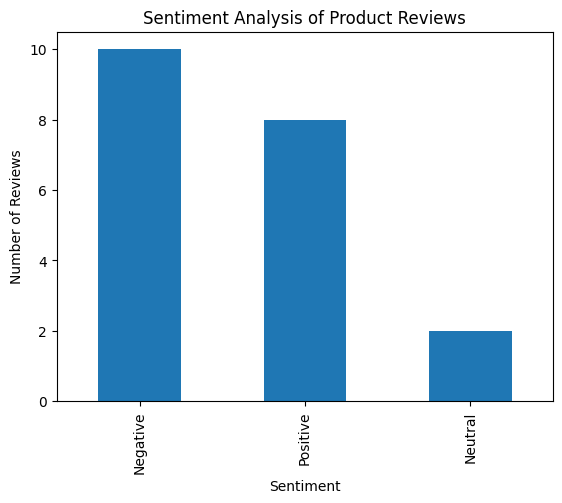

In [ ]:
import matplotlib.pyplot as plt

reviews_df["Sentiment_Label"].value_counts().plot(kind="bar")

plt.title("Sentiment Analysis of Product Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
reviews_df

,Review,Sentiment,Sentiment_Label
0,This product is excellent and very useful,0.695000,Positive
1,I really loved this product,0.700000,Positive
2,Amazing quality and fast delivery,0.400000,Positive
3,The product is very good,0.910000,Positive
4,I am happy with my purchase,0.800000,Positive
5,"Excellent experience, highly recommended",0.580000,Positive
6,The quality is okay,0.500000,Positive
7,The product is average,-0.150000,Negative
8,Delivery was on time,0.000000,Neutral
9,It is an ordinary product,-0.250000,Negative


In [ ]:
import pandas as pd

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
reviews_df["Sentiment"] = reviews_df["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews_df.head()

,Review,Sentiment,Sentiment_Label
0,This product is excellent and very useful,0.695,Positive
1,I really loved this product,0.700,Positive
2,Amazing quality and fast delivery,0.400,Positive
3,The product is very good,0.910,Positive
4,I am happy with my purchase,0.800,Positive


In [ ]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_df["Sentiment_Label"] = reviews_df["Sentiment"].apply(get_sentiment)

reviews_df

,Review,Sentiment,Sentiment_Label
0,This product is excellent and very useful,0.695000,Positive
1,I really loved this product,0.700000,Positive
2,Amazing quality and fast delivery,0.400000,Positive
3,The product is very good,0.910000,Positive
4,I am happy with my purchase,0.800000,Positive
5,"Excellent experience, highly recommended",0.580000,Positive
6,The quality is okay,0.500000,Positive
7,The product is average,-0.150000,Negative
8,Delivery was on time,0.000000,Neutral
9,It is an ordinary product,-0.250000,Negative


In [ ]:
sentiment_counts = reviews_df["Sentiment_Label"].value_counts()

print(sentiment_counts)

Sentiment_Label
Negative    10
Positive     8
Neutral      2
Name: count, dtype: int64


In [ ]:
sentiment_percentage = (
    reviews_df["Sentiment_Label"].value_counts(normalize=True) * 100
)

print(sentiment_percentage)

Sentiment_Label
Negative    50.0
Positive    40.0
Neutral     10.0
Name: proportion, dtype: float64


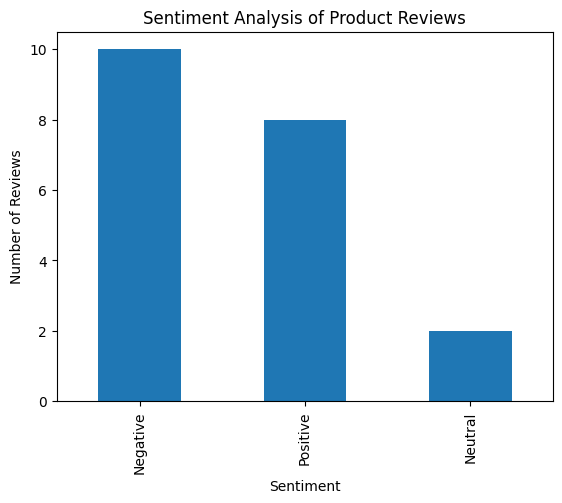

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Analysis of Product Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
reviews_df

,Review,Sentiment,Sentiment_Label
0,This product is excellent and very useful,0.695000,Positive
1,I really loved this product,0.700000,Positive
2,Amazing quality and fast delivery,0.400000,Positive
3,The product is very good,0.910000,Positive
4,I am happy with my purchase,0.800000,Positive
5,"Excellent experience, highly recommended",0.580000,Positive
6,The quality is okay,0.500000,Positive
7,The product is average,-0.150000,Negative
8,Delivery was on time,0.000000,Neutral
9,It is an ordinary product,-0.250000,Negative


In [ ]:
sentiment_counts = reviews_df["Sentiment_Label"].value_counts()

print(sentiment_counts)

Sentiment_Label
Negative    10
Positive     8
Neutral      2
Name: count, dtype: int64


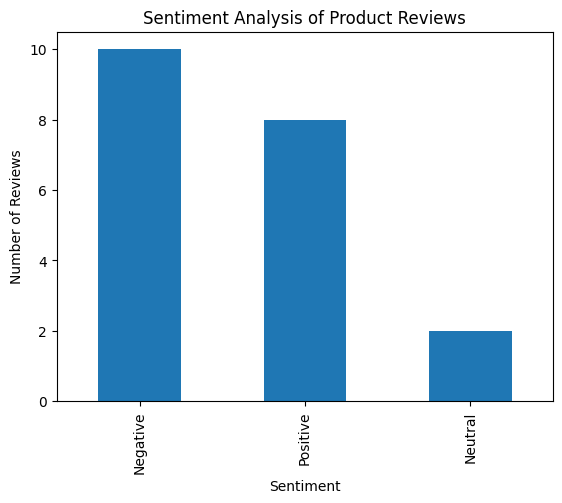

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Analysis of Product Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
print("TASK 4 - SENTIMENT ANALYSIS")
print("----------------------------")

print("Total Reviews:", len(reviews_df))
print("\nSentiment Counts:")
print(sentiment_counts)

print("\nConclusion:")
print("Positive reviews show customer satisfaction.")
print("Negative reviews show areas where the product can be improved.")
print("Neutral reviews show customers with an average opinion.")

TASK 4 - SENTIMENT ANALYSIS
----------------------------
Total Reviews: 20

Sentiment Counts:
Sentiment_Label
Negative    10
Positive     8
Neutral      2
Name: count, dtype: int64

Conclusion:
Positive reviews show customer satisfaction.
Negative reviews show areas where the product can be improved.
Neutral reviews show customers with an average opinion.
